### <font color='blue'> 0. Import all necessary Libraries </font>

In [2]:
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")
!pip install rdkit
!pip install tensorflow
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
import pandas as pd
import numpy as np
import rdkit
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

print("works")
%matplotlib inline

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


I0000 00:00:1776200081.375511 3146271 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776200081.379118 3146271 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776200081.416513 3146271 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776200093.064043 3146271 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

works


In [6]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "data"

### <font color='blue'> 1. Data preparation </font>
Load table and use important columns

In [65]:
# Load data
df = pd.read_csv(DATA / "GPCR.csv", index_col=0, sep=";")
df = df.reset_index(drop=True)
df.head()

# Check the dimension and missing value of the data
print("Shape of dataframe : ", df.shape)
df.info()

,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,Standard Value,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,NaN,NaN,491.60,1.0,6.70,BDBM349625,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(CCN...,IC50,'<',1000.0,...,CHEMBL5726517,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,1000.0
1,NaN,NaN,507.60,2.0,6.54,BDBM349626,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,IC50,'<',50000.0,...,CHEMBL5726517,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,50000.0
2,NaN,NaN,521.63,2.0,6.93,BDBM349627,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,IC50,'<',50000.0,...,CHEMBL5726517,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,50000.0
3,NaN,NaN,535.66,2.0,7.32,BDBM349628,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,IC50,'<',1000.0,...,CHEMBL5726517,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,1000.0
4,NaN,NaN,491.63,1.0,7.27,BDBM349618,CCN(CC)CCc1ccc(Oc2c(C(=O)c3c(C)cc(F)cc3C)sc3cc...,IC50,'<',1000.0,...,CHEMBL5726517,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,1000.0


Shape of dataframe :  (141, 47)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule Name               2 non-null      object 
 1   Molecule Max Phase          2 non-null      float64
 2   Molecular Weight            137 non-null    float64
 3   #RO5 Violations             137 non-null    float64
 4   AlogP                       137 non-null    float64
 5   Compound Key                141 non-null    object 
 6   Smiles                      137 non-null    object 
 7   Standard Type               141 non-null    object 
 8   Standard Relation           141 non-null    object 
 9   Standard Value              141 non-null    float64
 10  Standard Units              141 non-null    object 
 11  pChEMBL Value               91 non-null     float64
 12  Data Validity Comment       0 non-null      float64
 13  Com

In [47]:
#Preprocessing data
#Eliminate 0-values, turn into pIC50, keep necessary columns
chembl_df = df.copy()
chembl_df = chembl_df[chembl_df["Standard Value"] > 0].copy()
chembl_df = chembl_df[chembl_df["Smiles"].notnull()]
chembl_df["pIC50"]=(-1)*np.log10(chembl_df["Standard Value"]/(1000000000))
chembl_df = chembl_df[["Smiles","pIC50"]]
chembl_df.head()

,Smiles,pIC50
0,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(CCN...,6.00000
1,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,4.30103
2,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,4.30103
3,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,6.00000
4,CCN(CC)CCc1ccc(Oc2c(C(=O)c3c(C)cc(F)cc3C)sc3cc...,6.00000


pIC50    10.39794
dtype: float64

### <font color='blue'> 2. Molecular encoding</font>

In [39]:
# needed to import rdkit as a whole because it would give an error message when trying to apply function
# error says "name 'rdkit' is not defined"
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = rdkit.Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [40]:
# Converting SMILES to MACCS fingerprints
chembl_df["fingerprints_df"] = chembl_df["Smiles"].apply(smiles_to_fp)
# Look at head
print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (137, 3)


,Smiles,pIC50,fingerprints_df
0,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(CCN...,6.00000,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ..."
1,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,4.30103,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ..."
2,Cc1cc(F)cc(C)c1C(=O)c1sc2cc(O)ccc2c1-c1ccc(OCC...,4.30103,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [41]:
# Split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df2["fingerprints_df"], chembl_df2["pIC50"], test_size=0.3, random_state=42
)
# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)
# NBVAL_CHECK_OUTPUT

Shape of training data: (95,)
Shape of test data: (42,)


### <font color='blue'> 3. Define Neural Network </font>

In [42]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

### <font color='blue'> 4. Train The Model </font>


In [43]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 50
layer1_size = 64
layer2_size = 32

<Axes: >

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 56.5439 - mae: 7.3425 - mse: 56.5439 - val_loss: 43.9527 - val_mae: 6.4923 - val_mse: 43.9527
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37.4440 - mae: 5.9256 - mse: 37.4440 - val_loss: 28.0302 - val_mae: 5.1212 - val_mse: 28.0302
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.2152 - mae: 4.4633 - mse: 22.2152 - val_loss: 14.4768 - val_mae: 3.5467 - val_mse: 14.4768
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.3197 - mae: 2.8321 - mse: 10.3197 - val_loss: 5.1452 - val_mae: 1.9093 - val_mse: 5.1452
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.3117 - mae: 1.5231 - mse: 3.3117 - val_loss: 2.1003 - val_mae: 1.2383 - val_mse: 2.1003
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2951 - mae: 1.2157 - mse: 2.2951 - val_loss: 2.8701 - val_mae: 1.4237 - val_mse: 2.8701
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7434 - mae: 1.2784 - mse: 2.7434 - val_loss: 2.5668

Text(0, 0.5, 'loss')

Text(0.5, 0, 'epoch')

(0.0, 70.0)

...

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 79.1553 - mae: 8.7373 - mse: 79.1553 - val_loss: 71.4574 - val_mae: 8.3125 - val_mse: 71.4574
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 70.7684 - mae: 8.2484 - mse: 70.7684 - val_loss: 64.3756 - val_mae: 7.8794 - val_mse: 64.3756
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 63.6057 - mae: 7.8091 - mse: 63.6057 - val_loss: 58.3449 - val_mae: 7.4951 - val_mse: 58.3449
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 57.4823 - mae: 7.4195 - mse: 57.4823 - val_loss: 53.2555 - val_mae: 7.1550 - val_mse: 53.2555
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 52.5115 - mae: 7.0813 - mse: 52.5115 - val_loss: 48.8975 - val_mae: 6.8489 - val_mse: 48.8975
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 48.2457 - mae: 6.7821 - mse: 48.2457 - val_loss: 45.2368 - val_mae: 6.5811 - val_mse: 45.2368
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 44.5590 - mae: 6.5092 - mse: 44.5590

Text(0, 0.5, 'loss')

Text(0.5, 0, 'epoch')

(0.0, 70.0)

Text(0.5, 1.0, 'test loss = 0.86, batch size = 64')

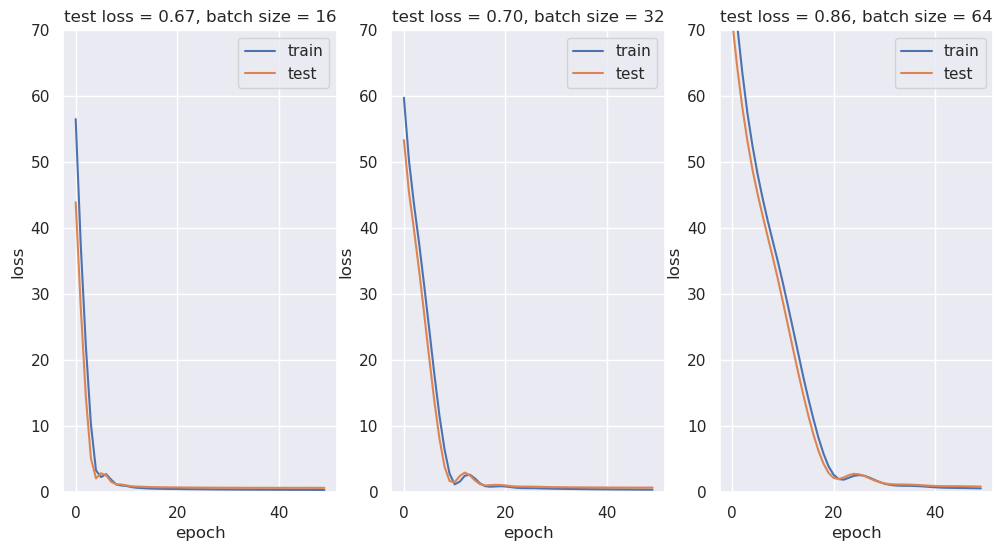

In [51]:
# Plot
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        np.array(list((x_train))).astype(float),
        y_train.values,
        batch_size=batch,
        validation_data=(np.array(list((x_test))).astype(float), y_test.values),
        verbose=1,
        epochs=nb_epoch,
    )
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 70))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()

In [53]:
# Save the trained model
filepath = DATA / "best_weights_diff_targ.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=1,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model
# batch size 32 because test loss lowest among the three
model.fit(
    np.array(list((x_train))).astype(float),
    y_train.values,
    epochs=nb_epoch,
    batch_size=16,
    callbacks=callbacks_list,
    verbose=1,
)

Epoch 1/50
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2195 - mae: 0.4004 - mse: 0.2195
Epoch 1: loss improved from None to 0.30505, saving model to /storage/homefs/xc20t071/data/best_weights_diff_targ.weights.h5

Epoch 1: finished saving model to /storage/homefs/xc20t071/data/best_weights_diff_targ.weights.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3051 - mae: 0.4109 - mse: 0.3051 
Epoch 2/50
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2731 - mae: 0.4068 - mse: 0.2731
Epoch 2: loss improved from 0.30505 to 0.30307, saving model to /storage/homefs/xc20t071/data/best_weights_diff_targ.weights.h5

Epoch 2: finished saving model to /storage/homefs/xc20t071/data/best_weights_diff_targ.weights.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3031 - mae: 0.4102 - mse: 0.3031 
Epoch 3/50
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3994 - mae: 0.4760 - mse: 0.3994
Epoch 3: loss did not improve from 0.30307
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3047 - mae: 0.4131 - 

### <font color='blue'> 5. Evaluation & prediction on test set </font>

In [54]:
# Evalute the model
print(f"Evaluate the model on the test data")
scores = model.evaluate(np.array(list((x_test))), y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

Evaluate the model on the test data
 loss: 0.70
 mse (same as loss): 0.70
 mae: 0.65


In [55]:
# Predict pIC50 values on x_test data
y_pred = model.predict(np.array(list((x_test))))

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
8.20
7.87
6.40
8.38
9.40


Text(0.5, 0, 'Predicted values')

Text(0, 0.5, 'True values')

Text(0.5, 1.0, 'Scatter plot: pIC50 values')

(0.0, 15.0)

(0.0, 15.0)

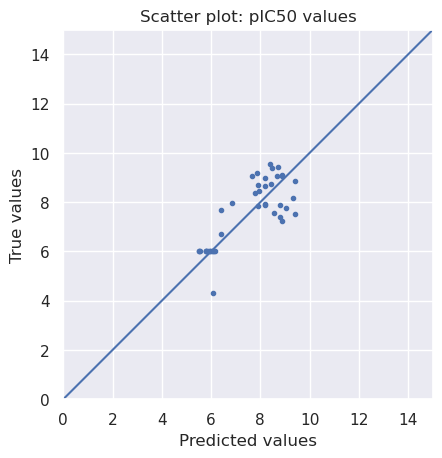

In [56]:
# Scatter plot
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

### <font color='blue'> 6. Prediction on external/unlabeled data </font>

In [57]:
# Load external/unlabeled data set
external_data = pd.read_csv(DATA / "test.csv", index_col=0)
external_data = external_data.reset_index(drop=True)
external_data.head()
# NBVAL_CHECK_OUTPUT

,SMILES
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...


In [58]:
# Convert SMILES strings to MACCS fingerprints
external_data["fingerprints_df"] = external_data["SMILES"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe : ", external_data.shape)
external_data.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe :  (3, 2)


,SMILES,fingerprints_df
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [59]:
# Prediction on external/unlabeled data
predictions = model.predict(
    np.array(list((external_data["fingerprints_df"]))).astype(float), callbacks=callbacks_list
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = external_data.join(predicted_pIC50)

predicted_pIC50_df.head(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


,SMILES,fingerprints_df,predicted_pIC50
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2.779246
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.560950
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.119081


In [61]:
# Save the predicted values in a csv file in the data folder
predicted_pIC50_df.to_csv(DATA / "predicted_pIC50_df_diff_targ.csv")

In [62]:
# Select top 3 drugs
predicted_pIC50_df = pd.read_csv(DATA / "predicted_pIC50_df_diff_targ.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
top3_drug

,SMILES,fingerprints_df,predicted_pIC50
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,5.119080
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,3.560950
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,2.779246


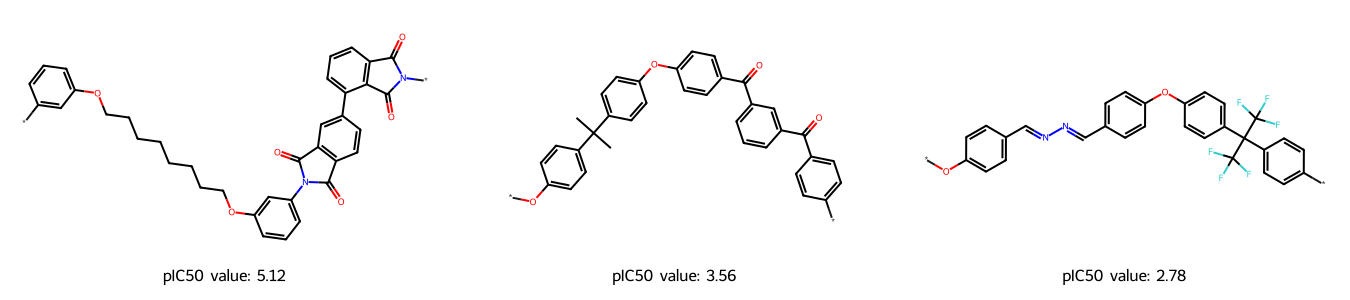

In [63]:
# Draw the drug molecules
highest_pIC50 = predicted_pIC50_df["SMILES"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)

# Discussion
Test loss with this data set a lot smaller but the data set itself a lot smaller by a magnitude of 3 (ca  180'000 vs 150).
Test loss validity is questioned due to small size of data set. Possibly unsuitable for training a model.